### This notebook captures all the models that could potentially help us make good predictions of smokers given our cleaned dataframe

Few things to note before we proceed 
1. Our dataset has imbalances in target variable '_RFSMOK3'
2. It has highly imbalanced features as well
3. Since we are more interested to know how many smokers are model is able to identify, we are interested in models that give us good prediction scores
    for imbalanced data.
4. From this high level overview, we want to evaluate the prediction capaciy of our model using 3 methods -
    1. CatBoost
    2. LightGBM

### 1. Import X_train/X_test for Encoded and Original datasets

In [8]:
### 1. Data import from Feature Engineering Notebook
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
# Load training/ test data
#original data from data/modeling directory
# Load when needed
with open('../data/modeling/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']

# Load encoded data from data/modeling directory
with open('../data/modeling/data_splits_encoded.pkl', 'rb') as f:
    encoded_data = pickle.load(f)
    X_train_encoded = encoded_data['X_train']
    X_test_encoded = encoded_data['X_test']
    y_train_encoded = encoded_data['y_train']
    y_test_encoded = encoded_data['y_test']



In [9]:
#check shape of the imported data
print(f"Encoded Train shape: {X_train_encoded.shape}, Test shape: {X_test_encoded.shape}")
print(f"Original Train shape: {X_train.shape}, Test shape: {X_test.shape}")
# check shape of the target variable
print(f"Encoded y_train shape: {y_train_encoded.shape}, y_test shape: {y_test_encoded.shape}")
print(f"Original y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")


Encoded Train shape: (1849209, 112), Test shape: (462303, 112)
Original Train shape: (1849209, 48), Test shape: (462303, 48)
Encoded y_train shape: (1849209,), y_test shape: (462303,)
Original y_train shape: (1849209,), y_test shape: (462303,)


In [10]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1849209 entries, 1395283 to 755824
Columns: 112 entries, CHILDREN to _AGE65YR_2
dtypes: bool(109), float64(3)
memory usage: 248.7 MB


In [11]:
X_train_encoded.select_dtypes(include=['float64']).columns.tolist()

['CHILDREN', 'WEIGHT2', 'HEIGHT3']

### 2. Apply Machine Learning Models

#### 2.1 CATBOOST Algorithm

#### 2.1.1 Default model

In [31]:
#generate a default CatBoost model
from catboost import CatBoostClassifier
import time
# Define categorical columns for CatBoost
catboost_categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# CatBoost model optimized for imbalanced classification
model = CatBoostClassifier(
    auto_class_weights='Balanced',
    cat_features=catboost_categorical_cols
)
# Fill missing values in categorical columns with string 'missing'
for col in catboost_categorical_cols:
    X_train[col] = X_train[col].astype(str).fillna('7')
    X_test[col] = X_test[col].astype(str).fillna('7')
print("Training CatBoost model...")

start = time.time()


model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True,
    verbose=100,
    plot=False
)

# model.fit(...)
end = time.time()


# Save the trained model
model.save_model('../data/modeling/catboost_model_default.cbm')

for col in catboost_categorical_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str).fillna('7')

y_pred_cat = model.predict(X_test)
y_proba_cat = model.predict_proba(X_test)[:, 1]  # Probability of smoking


print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")

cat_time = end - start


Training CatBoost model...
Learning rate set to 0.203168
0:	learn: 0.6612479	test: 0.6614399	best: 0.6614399 (0)	total: 1.61s	remaining: 26m 51s
100:	learn: 0.5489883	test: 0.5515269	best: 0.5515269 (100)	total: 1m 58s	remaining: 17m 35s
200:	learn: 0.5447822	test: 0.5486435	best: 0.5486435 (200)	total: 3m 57s	remaining: 15m 44s
300:	learn: 0.5427531	test: 0.5477489	best: 0.5477489 (300)	total: 6m 1s	remaining: 14m
400:	learn: 0.5413333	test: 0.5473877	best: 0.5473877 (400)	total: 8m 10s	remaining: 12m 12s
500:	learn: 0.5401444	test: 0.5471517	best: 0.5471517 (500)	total: 10m 20s	remaining: 10m 17s
600:	learn: 0.5391010	test: 0.5469903	best: 0.5469720 (577)	total: 12m 30s	remaining: 8m 18s
700:	learn: 0.5382284	test: 0.5469784	best: 0.5469627 (638)	total: 14m 42s	remaining: 6m 16s
800:	learn: 0.5373938	test: 0.5469351	best: 0.5469291 (791)	total: 16m 53s	remaining: 4m 11s
900:	learn: 0.5366275	test: 0.5469730	best: 0.5469291 (791)	total: 19m 10s	remaining: 2m 6s
999:	learn: 0.5359307	t

#### 2.1.2 Tuned model

In [13]:

from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score


print("\n" + "="*80)
print("CATBOOST MODEL FOR IMBALANCED BINARY CLASSIFICATION")
print("="*80)

# Remove target column from categorical_cols if present
catboost_categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# CatBoost model optimized for imbalanced classification
tuned_model = CatBoostClassifier(
    # Basic parameters
    iterations=1000,
    learning_rate=0.1,
    depth=8,
    
    # Handle categorical features
    cat_features=catboost_categorical_cols,
    
    # Imbalance handling
    auto_class_weights='Balanced',  # Automatically balance class weights
    # Alternatively: class_weights={0: 1, 1: 10}  # Manual weights
    
    # Evaluation and early stopping
    eval_metric='AUC',  # Good for imbalanced data
    use_best_model=True,
    early_stopping_rounds=100,
    
    # Regularization to prevent overfitting
    l2_leaf_reg=3,
    bagging_temperature=0.5,
    
    # Performance
    random_seed=42,
    verbose=200,
    
    # Model interpretability
    leaf_estimation_method='Newton'
)


# Fill missing values in categorical columns with string 'missing'
for col in catboost_categorical_cols:
    X_train[col] = X_train[col].astype(str).fillna('7')
    X_test[col] = X_test[col].astype(str).fillna('7')


start = time.time()

print("Training CatBoost model...")
tuned_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    plot=False
)
end = time.time()

print(f"Training completed!")
print(f"Best iteration: {tuned_model.get_best_iteration()}")
print(f"Best validation AUC: {tuned_model.get_best_score()['validation']['AUC']:.4f}")

# Save the trained model
tuned_model.save_model('../data/modeling/catboost_model_tuned.cbm')

for col in catboost_categorical_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str).fillna('7')

y_pred_cat_tuned = tuned_model.predict(X_test)
y_proba_cat_tuned = tuned_model.predict_proba(X_test)[:, 1]  # Probability of smoking


print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")

cat_tuned_time = end - start



CATBOOST MODEL FOR IMBALANCED BINARY CLASSIFICATION
Training CatBoost model...
0:	test: 0.7286490	best: 0.7286490 (0)	total: 1.35s	remaining: 22m 27s
200:	test: 0.7944612	best: 0.7944612 (200)	total: 5m 4s	remaining: 20m 10s
400:	test: 0.7963617	best: 0.7963617 (400)	total: 10m 27s	remaining: 15m 37s
600:	test: 0.7967918	best: 0.7967981 (591)	total: 16m 2s	remaining: 10m 39s
800:	test: 0.7969135	best: 0.7969305 (782)	total: 21m 43s	remaining: 5m 23s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7969304967
bestIteration = 782

Shrink model to first 783 iterations.
Training completed!
Best iteration: 782
Best validation AUC: 0.7969

TIME TAKEN FOR TRAINING:
1451.37 seconds


### 2.2 LightGBM model

### 2.2.1 Default Model

In [14]:
# Import
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
from lightgbm.callback import early_stopping  # Correct import

# Convert object columns to category
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Get valid categorical columns
lightGBM_categorical_cols = X_train.select_dtypes(include='category').columns.tolist()

print("LightGBM Categorical Columns:")
print(lightGBM_categorical_cols)
print("="*80)

#Drop DATE columns from encoded data
X_train.drop(columns=['IDATE'], inplace=True, errors='ignore')
X_test.drop(columns=['IDATE'], inplace=True, errors='ignore')

# Define LightGBM model with basic parameters
lgbm_model = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=1000,  # Set higher to allow early stopping
    random_state=42,
    class_weight='balanced'  # Handles class imbalance

)

start = time.time()
# Fit the model
lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
    categorical_feature=lightGBM_categorical_cols,  # Can be column names or indices
)
end = time.time()

# Save the trained LightGBM model
lgbm_model.booster_.save_model('../data/modeling/lightgbm_model_default.txt')

# Predict
y_pred_lgbm = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Evaluate
print("AUC Score:", roc_auc_score(y_test, y_proba_lgbm))
print(classification_report(y_test, y_pred_lgbm))

print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")

lGBM_time = end - start


LightGBM Categorical Columns:
['DISPCODE', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'SEX', 'MARITAL', 'RENTHOM1', 'VETERAN3', 'QLACTLM2', 'USEEQUIP', 'EXERANY2', 'PNEUVAC3', 'HIVTST6', '_RFHLTH', '_HCVU651', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', 'DRNKANY5', '_RFBING5', '_TOTINDA', '_RFSEAT3', 'YEAR', 'DIABETES', '_AGE65YR']
[LightGBM] [Info] Number of positive: 291946, number of negative: 1557263
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 526
[LightGBM] [Info] Number of data points in the train set: 1849209, number of used features: 48
[LightGBM] [Info] [

### 2.2.2 Tuned Model

In [15]:
import time
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from lightgbm.callback import early_stopping
import joblib

# Convert object columns to category
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Drop irrelevant date columns
X_train.drop(columns=['IDATE'], inplace=True, errors='ignore')
X_test.drop(columns=['IDATE'], inplace=True, errors='ignore')



# Categorical columns for LightGBM
categorical_cols = X_train.select_dtypes(include='category').columns.tolist()

# Base model
lgbm = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    n_estimators=1000,  # Allows for early stopping
    random_state=42,
    class_weight='balanced'  # Helps with imbalance
)

# # Hyperparameter distribution for randomized search
# param_dist = {
#     'num_leaves': [31, 63, 127],
#     'max_depth': [-1, 5, 10, 15],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'min_child_samples': [10, 20, 50],  # Reduce
#     'min_split_gain': [0, 0.001],       # Allow smaller gains
#     'subsample': [0.7, 0.9, 1.0],
#     'colsample_bytree': [0.7, 0.9, 1.0]
# }

param_dist = {
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [5, 10, 20],
    'min_split_gain': [0, 0.001],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5]
}


# Randomized search
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=False,
    n_jobs=1,
    random_state=42
)
start_time = time.time()

# Fit with early stopping
random_search.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=30, verbose=False)],
    categorical_feature=categorical_cols
)

end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

# Best model
best_lgbm = random_search.best_estimator_
print("Best Params:", random_search.best_params_)

# Save model
joblib.dump(best_lgbm, '../data/modeling/lightgbm_model_tuned.pkl')

# Predict and evaluate
y_pred_lgbm_tuned = best_lgbm.predict(X_test)
y_proba_lgbm_tuned = best_lgbm.predict_proba(X_test)[:, 1]

print("Tuned AUC Score:", roc_auc_score(y_test, y_proba_lgbm_tuned))
print(classification_report(y_test, y_pred_lgbm_tuned))

print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")




[LightGBM] [Info] Number of positive: 194631, number of negative: 1038175
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.046376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 532
[LightGBM] [Info] Number of data points in the train set: 1232806, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 194631, number of negative: 1038175
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044420 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 531
[LightGBM] [Info] Number of data points in the train set: 1232806, number of used features: 48
[LightGBM]

In [16]:
lGBM_tuned_time = end_time - start_time
print(f"LightGBM Tuned Training Time: {lGBM_tuned_time:.2f} seconds")


LightGBM Tuned Training Time: 2678.78 seconds


### 3. MODEL EVALUATION

#### 3.1 Base results

In [17]:
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
import pandas as pd
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import numpy as np



def evaluate_model(model, y_test, y_pred, y_proba, categorical_cols, model_type):
    print("\n" + "="*80)
    print(f"{model_type} EVALUATION")
    print("="*80)


    # Comprehensive evaluation metrics for imbalanced data
    print("Classification Metrics:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall (Sensitivity): {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

    # Detailed classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, 
                        index=['Actual Non-smoking', 'Actual Smoking'],
                        columns=['Predicted Non-smoking', 'Predicted Smoking'])
    print(cm_df)

    # Smoking Detection Breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\nSmoking Detection Metrics:")
    print(f"True Positives (Smokers caught): {tp}")
    print(f"False Positives (False alarms): {fp}")
    print(f"False Negatives (Missed smokers): {fn}")
    print(f"True Negatives (Correctly identified non-smokers): {tn}")
    print(f"False Positive Rate: {fp / (fp + tn):.4f}")
    print(f"False Negative Rate: {fn / (fn + tp):.4f}")

    print("\n" + "="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    # Use feature_importances_ and feature names from X_train
    if model_type == "LightGBM":
        feature_importance = model.feature_importances_
        feature_names = model.feature_name_
    else:
        feature_importance = model.get_feature_importance()
        feature_names = model.feature_names_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance,
        'type': ['Categorical' if col in categorical_cols else 'Numerical' 
                for col in feature_names]
    }).sort_values('importance', ascending=False)

    print("Top 15 Most Important Features:")
    print(importance_df.head(15))

    print(f"\nImportance by feature type:")
    type_importance = importance_df.groupby('type')['importance'].sum()
    print(type_importance)

    return cm_df, tn, fp, fn, tp, importance_df, type_importance



#### 3.2 Best Threshold result

In [18]:
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
import pandas as pd
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import numpy as np



def evaluate_model_best_threshold(model, y_test, y_pred, y_proba, categorical_cols, model_type):
    print("\n" + "="*80)
    print(f"{model_type} EVALUATION")
    print("="*80)

    #get best threashold for precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precision[:-1], label="Precision", color="b")
    plt.plot(thresholds, recall[:-1], label="Recall", color="g")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision-Recall vs Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()


    # Compute F1 score efficiently: F1 = 2 * (P * R) / (P + R)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

    # Find best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    print("Best F1 Threshold:", best_threshold)

    # Apply best threshold to predictions
    y_pred_custom = (y_proba >= best_threshold).astype(int)

    # Comprehensive evaluation metrics for imbalanced data
    print("Classification Metrics:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_custom):.4f}")
    print(f"Recall (Sensitivity): {recall_score(y_test, y_pred_custom):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_custom):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

    # Detailed classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred_custom))

    # Confusion Matrix
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_custom)
    cm_df = pd.DataFrame(cm, 
                        index=['Actual Non-smoking', 'Actual Smoking'],
                        columns=['Predicted Non-smoking', 'Predicted Smoking'])
    print(cm_df)

    # Smoking Detection Breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\nSmoking Detection Metrics:")
    print(f"True Positives (Smokers caught): {tp}")
    print(f"False Positives (False alarms): {fp}")
    print(f"False Negatives (Missed smokers): {fn}")
    print(f"True Negatives (Correctly identified non-smokers): {tn}")
    print(f"False Positive Rate: {fp / (fp + tn):.4f}")
    print(f"False Negative Rate: {fn / (fn + tp):.4f}")

    print("\n" + "="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    # Use feature_importances_ and feature names from X_train
    if model_type == "LightGBM":
        feature_importance = model.feature_importances_
        feature_names = model.feature_name_
    else:
        feature_importance = model.get_feature_importance()
        feature_names = model.feature_names_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance,
        'type': ['Categorical' if col in categorical_cols else 'Numerical' 
                for col in feature_names]
    }).sort_values('importance', ascending=False)

    print("Top 15 Most Important Features:")
    print(importance_df.head(15))

    print(f"\nImportance by feature type:")
    type_importance = importance_df.groupby('type')['importance'].sum()
    print(type_importance)

    return cm_df, tn, fp, fn, tp, importance_df, type_importance



#### 3.3 CATBOOST ALGORITHM - Evaluate Metrics for Base and Best Threshold 


CatBoost EVALUATION
Classification Metrics:
Accuracy: 0.7296
Precision: 0.3335
Recall (Sensitivity): 0.7139
F1-Score: 0.4546
ROC-AUC: 0.7967
PR-AUC: 0.4581

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.82    389317
           1       0.33      0.71      0.45     72986

    accuracy                           0.73    462303
   macro avg       0.63      0.72      0.64    462303
weighted avg       0.84      0.73      0.76    462303


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 285189             104128
Actual Smoking                      20881              52105

Smoking Detection Metrics:
True Positives (Smokers caught): 52105
False Positives (False alarms): 104128
False Negatives (Missed smokers): 20881
True Negatives (Correctly identified non-smokers): 285189
False Positive Rate: 0.2675
False Negative Rate: 0.2861

FEATURE IMPORTANCE
T

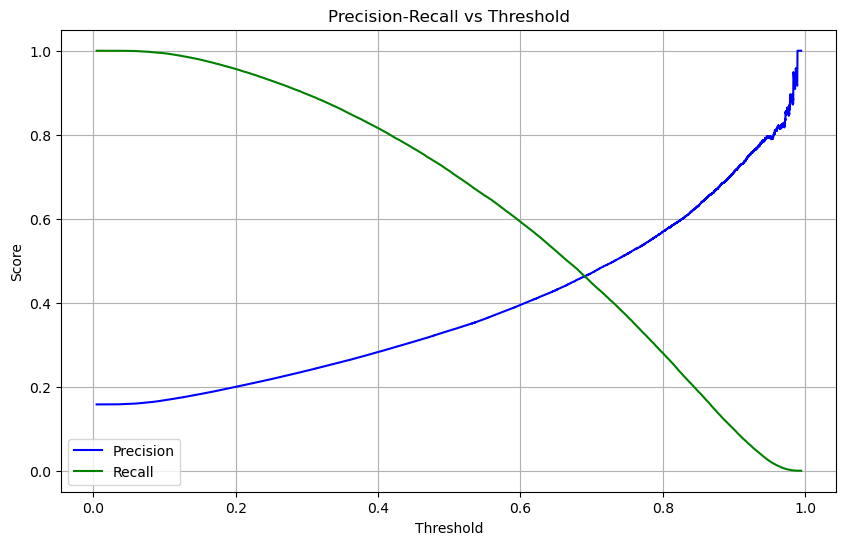

Best F1 Threshold: 0.6191377107277312
Classification Metrics:
Accuracy: 0.8019
Precision: 0.4083
Recall (Sensitivity): 0.5676
F1-Score: 0.4749
ROC-AUC: 0.7967
PR-AUC: 0.4581

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88    389317
           1       0.41      0.57      0.47     72986

    accuracy                           0.80    462303
   macro avg       0.66      0.71      0.68    462303
weighted avg       0.83      0.80      0.81    462303


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 329290              60027
Actual Smoking                      31562              41424

Smoking Detection Metrics:
True Positives (Smokers caught): 41424
False Positives (False alarms): 60027
False Negatives (Missed smokers): 31562
True Negatives (Correctly identified non-smokers): 329290
False Positive Rate: 0.1542
False Negative Rate: 0.4324

FEAT

In [19]:
# Evaluate the CatBoost model
# base evaluation
cm_df_cat, tn_cat, fp_cat, fn_cat, tp_cat, importance_df_cat, type_importance_cat = evaluate_model(model, y_test, y_pred_cat, y_proba_cat, catboost_categorical_cols, "CatBoost")
# Evaluate the CatBoost model with best threshold
cm_df_cat_best, tn_cat_best, fp_cat_best, fn_cat_best, tp_cat_best, importance_df_cat_best, type_importance_cat_best = evaluate_model_best_threshold(model, y_test, y_pred_cat, y_proba_cat, catboost_categorical_cols, "CatBoost")

#### 3.4 CATBOOST TUNED ALGORITHM - Evaluate model metrics for Base and Tuned models


CatBoost Tuned EVALUATION
Classification Metrics:
Accuracy: 0.7310
Precision: 0.3345
Recall (Sensitivity): 0.7119
F1-Score: 0.4552
ROC-AUC: 0.7969
PR-AUC: 0.4583

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.82    389317
           1       0.33      0.71      0.46     72986

    accuracy                           0.73    462303
   macro avg       0.63      0.72      0.64    462303
weighted avg       0.84      0.73      0.76    462303


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 285967             103350
Actual Smoking                      21028              51958

Smoking Detection Metrics:
True Positives (Smokers caught): 51958
False Positives (False alarms): 103350
False Negatives (Missed smokers): 21028
True Negatives (Correctly identified non-smokers): 285967
False Positive Rate: 0.2655
False Negative Rate: 0.2881

FEATURE IMPORT

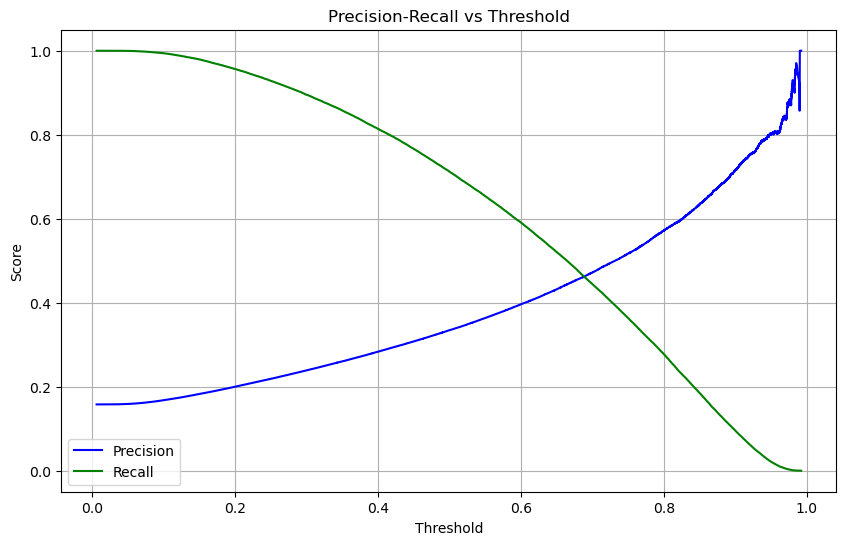

Best F1 Threshold: 0.6031839251331472
Classification Metrics:
Accuracy: 0.7950
Precision: 0.3985
Recall (Sensitivity): 0.5866
F1-Score: 0.4746
ROC-AUC: 0.7969
PR-AUC: 0.4583

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87    389317
           1       0.40      0.59      0.47     72986

    accuracy                           0.79    462303
   macro avg       0.66      0.71      0.67    462303
weighted avg       0.83      0.79      0.81    462303


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 324700              64617
Actual Smoking                      30171              42815

Smoking Detection Metrics:
True Positives (Smokers caught): 42815
False Positives (False alarms): 64617
False Negatives (Missed smokers): 30171
True Negatives (Correctly identified non-smokers): 324700
False Positive Rate: 0.1660
False Negative Rate: 0.4134

FEAT

In [20]:
#evaluate catboost tuned model
# base model
cm_df_cat_tuned, tn_cat_tuned, fp_cat_tuned, fn_cat_tuned, tp_cat_tuned, importance_df_cat_tuned, type_importance_cat_tuned= evaluate_model(tuned_model, y_test, y_pred_cat_tuned, y_proba_cat_tuned, catboost_categorical_cols, "CatBoost Tuned")
# best threshold
cm_df_cat_tune_best, tn_cat_tune_best, fp_cat_tune_best, fn_cat_tune_best, tp_cat_tune_best, importance_df_cat_tune_best, type_importance_cat_tune_best = evaluate_model_best_threshold(tuned_model, y_test, y_pred_cat_tuned, y_proba_cat_tuned, catboost_categorical_cols, "CatBoost Tuned")

#### 3.5 LIGHTGBM BASE MODEL - Evaluate metrics of Base and Best Threshold


LightGBM EVALUATION
Classification Metrics:
Accuracy: 0.7292
Precision: 0.3328
Recall (Sensitivity): 0.7118
F1-Score: 0.4535
ROC-AUC: 0.7960
PR-AUC: 0.4569

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.82    389317
           1       0.33      0.71      0.45     72986

    accuracy                           0.73    462303
   macro avg       0.63      0.72      0.64    462303
weighted avg       0.84      0.73      0.76    462303


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 285144             104173
Actual Smoking                      21032              51954

Smoking Detection Metrics:
True Positives (Smokers caught): 51954
False Positives (False alarms): 104173
False Negatives (Missed smokers): 21032
True Negatives (Correctly identified non-smokers): 285144
False Positive Rate: 0.2676
False Negative Rate: 0.2882

FEATURE IMPORTANCE
T

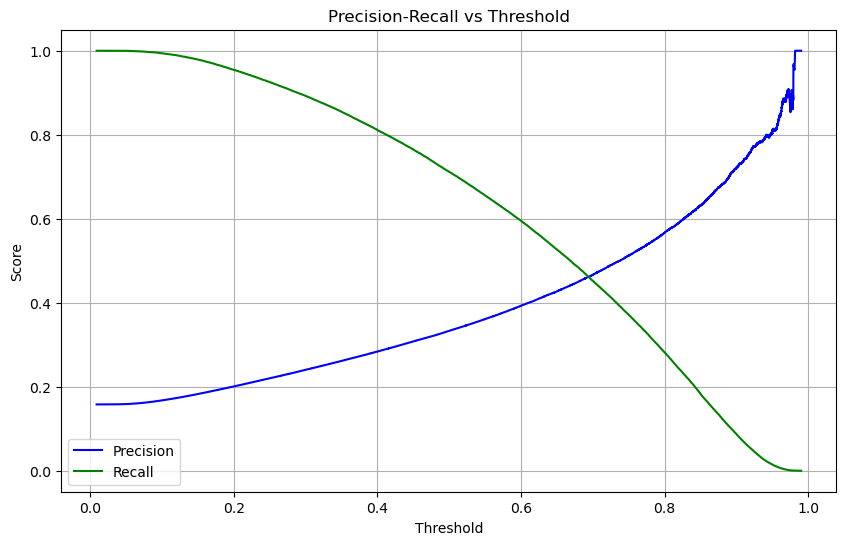

Best F1 Threshold: 0.624634837139487
Classification Metrics:
Accuracy: 0.8029
Precision: 0.4095
Recall (Sensitivity): 0.5627
F1-Score: 0.4740
ROC-AUC: 0.7960
PR-AUC: 0.4569

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88    389317
           1       0.41      0.56      0.47     72986

    accuracy                           0.80    462303
   macro avg       0.66      0.71      0.68    462303
weighted avg       0.83      0.80      0.81    462303


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 330106              59211
Actual Smoking                      31919              41067

Smoking Detection Metrics:
True Positives (Smokers caught): 41067
False Positives (False alarms): 59211
False Negatives (Missed smokers): 31919
True Negatives (Correctly identified non-smokers): 330106
False Positive Rate: 0.1521
False Negative Rate: 0.4373

FEATU

In [21]:
#evaluate the LightGBM model, 
# basic model
cm_df_lgbm, tn_lgbm, fp_lgbm, fn_lgbm, tp_lgbm, importance_df_lgbm, type_importance_lgbm = evaluate_model(lgbm_model, y_test, y_pred_lgbm, y_proba_lgbm, lightGBM_categorical_cols, "LightGBM")
# evaluate the LightGBM model with best threshold
cm_df_lgbm_best, tn_lgbm_best, fp_lgbm_best, fn_lgbm_best, tp_lgbm_best, importance_df_lgbm_best, type_importance_lgbm_best = evaluate_model_best_threshold(lgbm_model, y_test, y_pred_lgbm, y_proba_lgbm, lightGBM_categorical_cols, "LightGBM")

#### 3.6 LIGHTGBM TUNED ALGORITHM - Evaluate metrics for base and best threshold


LightGBM EVALUATION
Classification Metrics:
Accuracy: 0.7311
Precision: 0.3347
Recall (Sensitivity): 0.7117
F1-Score: 0.4552
ROC-AUC: 0.7967
PR-AUC: 0.4577

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.82    389317
           1       0.33      0.71      0.46     72986

    accuracy                           0.73    462303
   macro avg       0.63      0.72      0.64    462303
weighted avg       0.84      0.73      0.76    462303


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 286047             103270
Actual Smoking                      21044              51942

Smoking Detection Metrics:
True Positives (Smokers caught): 51942
False Positives (False alarms): 103270
False Negatives (Missed smokers): 21044
True Negatives (Correctly identified non-smokers): 286047
False Positive Rate: 0.2653
False Negative Rate: 0.2883

FEATURE IMPORTANCE
T

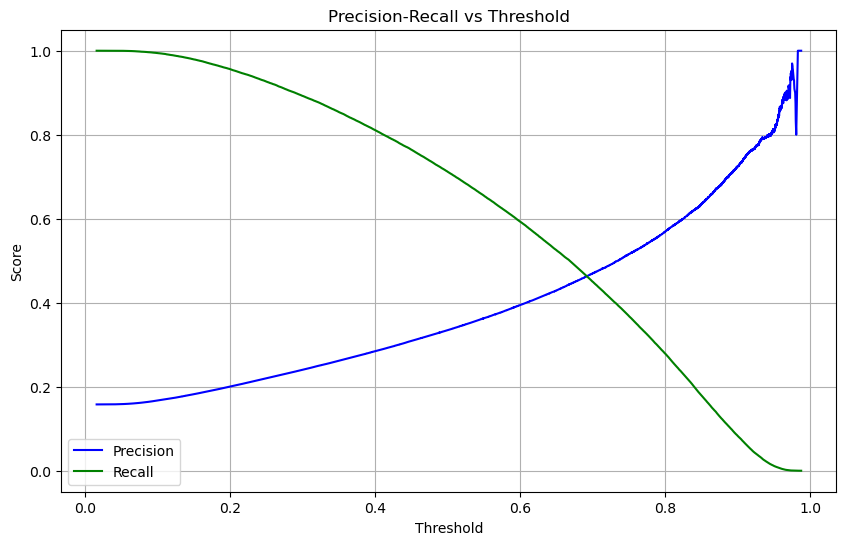

Best F1 Threshold: 0.6145894862137528
Classification Metrics:
Accuracy: 0.7993
Precision: 0.4044
Recall (Sensitivity): 0.5737
F1-Score: 0.4744
ROC-AUC: 0.7967
PR-AUC: 0.4577

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.88    389317
           1       0.40      0.57      0.47     72986

    accuracy                           0.80    462303
   macro avg       0.66      0.71      0.68    462303
weighted avg       0.83      0.80      0.81    462303


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 327647              61670
Actual Smoking                      31111              41875

Smoking Detection Metrics:
True Positives (Smokers caught): 41875
False Positives (False alarms): 61670
False Negatives (Missed smokers): 31111
True Negatives (Correctly identified non-smokers): 327647
False Positive Rate: 0.1584
False Negative Rate: 0.4263

FEAT

In [22]:
#evaluate the LightGBM tuned model
# base model
cm_df_lgbm_tuned, tn_lgbm_tuned, fp_lgbm_tuned, fn_lgbm_tuned, tp_lgbm_tuned, importance_df_lgbm_tuned, type_importance_lgbm_tuned = evaluate_model(best_lgbm, y_test, y_pred_lgbm_tuned, y_proba_lgbm_tuned, lightGBM_categorical_cols, "LightGBM")
# best threshold
cm_df_lgbm_tune_best, tn_lgbm_tune_best, fp_lgbm_tune_best, fn_lgbm_tune_best, tp_lgbm_tune_best, importance_df_lgbm_tune_best, type_importance_lgbm_tune_best = evaluate_model_best_threshold(best_lgbm, y_test, y_pred_lgbm_tuned, y_proba_lgbm_tuned, lightGBM_categorical_cols, "LightGBM")

### 4. Compare 4 models

In [23]:
### Compare values of Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-AUC for all models, also time taken for training
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

import numpy as np
# Create a DataFrame to compare metrics
comparison_df = pd.DataFrame({
    'Model': ['CatBoost', 'CatBoost Tuned', 'LightGBM', 'LightGBM Tuned'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_cat),
        accuracy_score(y_test, y_pred_cat_tuned),
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_lgbm_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_cat),
        precision_score(y_test, y_pred_cat_tuned),
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_lgbm_tuned)
    ],
    'Recall': [
        recall_score(y_test, y_pred_cat),
        recall_score(y_test, y_pred_cat_tuned),
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_lgbm_tuned)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_cat),
        f1_score(y_test, y_pred_cat_tuned),
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_lgbm_tuned)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_cat),
        roc_auc_score(y_test, y_proba_cat_tuned),
        roc_auc_score(y_test, y_proba_lgbm),
        roc_auc_score(y_test, y_proba_lgbm_tuned)
    ],
    'PR-AUC': [
        average_precision_score(y_test, y_proba_cat),
        average_precision_score(y_test, y_proba_cat_tuned),
        average_precision_score(y_test, y_proba_lgbm),
        average_precision_score(y_test, y_proba_lgbm_tuned)
    ],
    'Training Time': [
        cat_time,
        cat_tuned_time,
        lGBM_time,
        lGBM_tuned_time
    ]
})
# Set Model as index
comparison_df.set_index('Model', inplace=True)
# Display the comparison DataFrame
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df)

# Save the comparison DataFrame to a CSV file and an image
comparison_df.to_csv('../README_files/model_comparison.csv')
comparison_df.to_excel('../README_files/model_comparison.xlsx')




MODEL COMPARISON
                Accuracy  Precision    Recall  F1-Score   ROC-AUC    PR-AUC  \
Model                                                                         
CatBoost        0.729595   0.333508  0.713904  0.454631  0.796703  0.458064   
CatBoost Tuned  0.730960   0.334548  0.711890  0.455185  0.796930  0.458342   
LightGBM        0.729171   0.332768  0.711835  0.453523  0.796041  0.456888   
LightGBM Tuned  0.731098   0.334652  0.711671  0.455236  0.796749  0.457750   

                Training Time  
Model                          
CatBoost          1251.335701  
CatBoost Tuned    1451.369939  
LightGBM            23.419668  
LightGBM Tuned    2678.780145  


#### 4.1 Model Selection

1. **TRAINING TIME:** The results are almost similar for all models however we notice that **Light GBM** is the best model in terms of time taken to predict.(~16s), second best time is for **CatBoost**<br>
2. **GOOD RECALL:** Since our primary goal was to figure out the factors that are responsible or contribute towards a person smoking, we are more interested in the Recall (so that we can identify all possible reasons someone chooses to smoke for Public Health Intervention) of our model and therefore **CatBoost** is the best.<br>
3. **F1-SCORE:** The model **CatBoost** also gives the best F1-score i.e Precision to recall Ratio is best for this case, this shows that the results are balanced for behaviour study<br>
4. **PR-AUC:** Similarly, **CatBoost** perfoms best in this metric too.

### Therefore it is safe to say CATBOOST ALgorithm will yield us the best features to evaluate constructs responsible for smoking

### TOP PREDICTORS OF SMOKERS

#### 1. TOP features of CATBOOST Model

In [24]:
importance_df_cat.sort_values(by='importance', ascending=False)

,feature,importance,type
39,_EDUCAG,15.694558,Categorical
47,_AGE65YR,10.118157,Categorical
20,MARITAL,7.434242,Categorical
42,_RFBING5,6.173267,Categorical
24,WEIGHT2,5.380924,Numerical
14,CHCCOPD1,4.915996,Categorical
1,GENHLTH,4.565654,Categorical
32,_HCVU651,4.549186,Categorical
40,_INCOMG,4.207039,Categorical
25,HEIGHT3,3.537325,Numerical


In [25]:
# compare teh top 15 features of all models and find the common ones

top_features = pd.concat([
    importance_df_cat.head(15),
    importance_df_cat_tuned.head(15),
    importance_df_lgbm.head(15),
    importance_df_lgbm_tuned.head(15)
]).drop_duplicates(subset='feature').reset_index(drop=True)
print("\n" + "="*80)
print("TOP 15 FEATURES ACROSS ALL MODELS")
print("="*80)
print(top_features)


TOP 15 FEATURES ACROSS ALL MODELS
     feature  importance         type
0    _EDUCAG   15.694558  Categorical
1   _AGE65YR   10.118157  Categorical
2    MARITAL    7.434242  Categorical
3   _RFBING5    6.173267  Categorical
4    WEIGHT2    5.380924    Numerical
5   CHCCOPD1    4.915996  Categorical
6    GENHLTH    4.565654  Categorical
7   _HCVU651    4.549186  Categorical
8    _INCOMG    4.207039  Categorical
9    HEIGHT3    3.537325    Numerical
10   _RFBMI5    2.865511  Categorical
11   HIVTST6    2.802742  Categorical
12  ADDEPEV2    2.400352  Categorical
13  _TOTINDA    2.290498  Categorical
14  RENTHOM1    2.147631  Categorical
15  EXERANY2    2.411688  Categorical
16  PNEUVAC3  569.000000  Categorical
17  DRNKANY5  533.000000  Categorical
18      YEAR  462.000000  Categorical
19  CHILDREN  454.000000    Numerical
20  PERSDOC2  453.000000  Categorical
21  _CHLDCNT  427.000000  Categorical


### 5. Analysis

#### 5.1 Visualize influence of HBM construct on Smoking (via Bubble plot)

In [26]:
import pickle

# Replace '002-eda_final.pkl' with the actual filename if different
with open('../data/processed/002-eda_final.pkl', 'rb') as f:
    df = pickle.load(f)

df.head() # Display the first few rows of the DataFrame to verify successful loading


,DISPCODE,GENHLTH,PHYSHLTH,MENTHLTH,HLTHPLN1,PERSDOC2,MEDCOST,CHECKUP1,CVDINFR4,CVDCRHD4,...,_EDUCAG,_INCOMG,_RFSMOK3,DRNKANY5,_RFBING5,_TOTINDA,_RFSEAT3,YEAR,DIABETES,_AGE65YR
0,1200,5,3,4,1,1,2,1,2,2,...,2,2,0,2,1,2,1,2015,2,1
1,1100,3,1,1,2,1,1,4,2,2,...,4,1,1,2,1,1,2,2015,2,1
3,1100,5,4,4,1,2,1,1,2,2,...,2,5,0,2,1,2,1,2015,2,1
4,1100,5,4,1,1,1,2,1,2,2,...,3,5,0,2,1,2,1,2015,2,1
5,1100,2,1,1,1,1,2,1,2,2,...,1,4,0,2,1,1,1,2015,2,2


In [27]:

import matplotlib.pyplot as plt
import seaborn as sns
# Define HBM constructs and their corresponding features
# Health Belief Model (HBM) features for health-related analysis
# These features are based on the Health Belief Model, which includes:
# 1. Perceived Susceptibility
# 2. Perceived Severity
# 3. Perceived Benefits
# 4. Perceived Barriers
# 5. Cues to Action
# 6. Self-Efficacy
# 7. Other Variables

hbm_features = {
    'Perceived Susceptibility': [
        'CHCKIDNY',   # Kidney disease
        'CVDINFR4',   # Blood cholesterol check
        'CVDCRHD4',   # Coronary heart disease
        'CVDSTRK3',   # Stroke
        'ASTHMA3',    # Asthma
        'CHCSCNCR',   # Skin cancer
        'CHCOCNCR',   # Other cancer
        'CHCCOPD1',   # COPD
        'HAVARTH3',   # Arthritis
        'DIABETE3',   # Diabetes
        'ADDEPEV2',   # Depression
        'PNEUVAC3',   # Pneumonia vaccine
        'HIVTST6',    # HIV test
        '_RFHLTH',    # Self-rated health
        '_LTASTH1',   # Lifetime asthma
        '_CASTHM1',   # Current asthma
        '_ASTHMS1',   # Asthma status summary
        '_DRDXAR1',   # Arthritis diagnosis
        '_RFBMI5',    # BMI risk factor
        '_RFSMOK3',   # Smoking risk status
    ],
    'Perceived Severity': [
        'GENHLTH',    # General health
        '_RFHLTH',    # Self-rated health
        'QLACTLM2',   # Activity limitation
        'MENTHLTH',   # Mental health days
        'PHYSHLTH',   # Physical health days
        'USEEQUIP',   # Use special equipment
        'ADDEPEV2',   # Depression diagnosis
    ],
    'Perceived Benefits': [
        'CHECKUP1',   # Last routine checkup
        'HLTHPLN1',   # Health plan coverage
        'EXERANY2',   # Exercise
        'PERSDOC2',   # Personal doctor
        'PNEUVAC3',   # Pneumonia vaccine
        'HIVTST6',    # HIV test
        '_TOTINDA',   # Total physical activity
    ],
    'Perceived Barriers': [
        'MEDCOST',    # Could not see doctor due to cost
        '_INCOMG',    # Income group
        '_EDUCAG',    # Education group
        'RENTHOM1',   # Home ownership
        'VETERAN3',   # Veteran status
    ],
    'Cues to Action': [
        'CHECKUP1',   # Last checkup (doctor's advice)
        'DRNKANY5',   # Any alcohol in past 30 days
        'DROCDY3_',   # Days drank alcohol
        '_RFBING5',   # Binge drinking
        '_ASTHMS1',   # Asthma status
        'QLACTLM2',   # Activity limitation
        'PERSDOC2',   # Personal doctor
        '_RFSEAT3',   # Seatbelt use (proxy for health cues)
        'EXERANY2',   # Exercise
        'PNEUVAC3',   # Pneumonia vaccine
        'HIVTST6',    # HIV test
    ],
    'Self-Efficacy': [
        'WEIGHT2',    # Weight
        'HEIGHT3',    # Height
        '_RFBMI5',    # BMI category
        '_TOTINDA',   # Physical activity
        '_RFSEAT3',   # Seatbelt use
        'EXERANY2',   # Exercise
        'QLACTLM2',   # Activity limitation
    ],
    'Other Variables': [
        'YEAR',       # Year of survey
        '_AGE65YR',   # Age 65 or older
        '_AGE_G',     # Age group
        'SEX',        # Sex
        'MARITAL',    # Marital status
        'RENTHOM1',   # Home ownership
        'VETERAN3',   # Veteran status
        'CHILDREN',   # Number of children
        '_CHLDCNT',   # Child count
        '_STATE',     # State of residence
        'DISPCODE',   # Disposition code
    ]
}

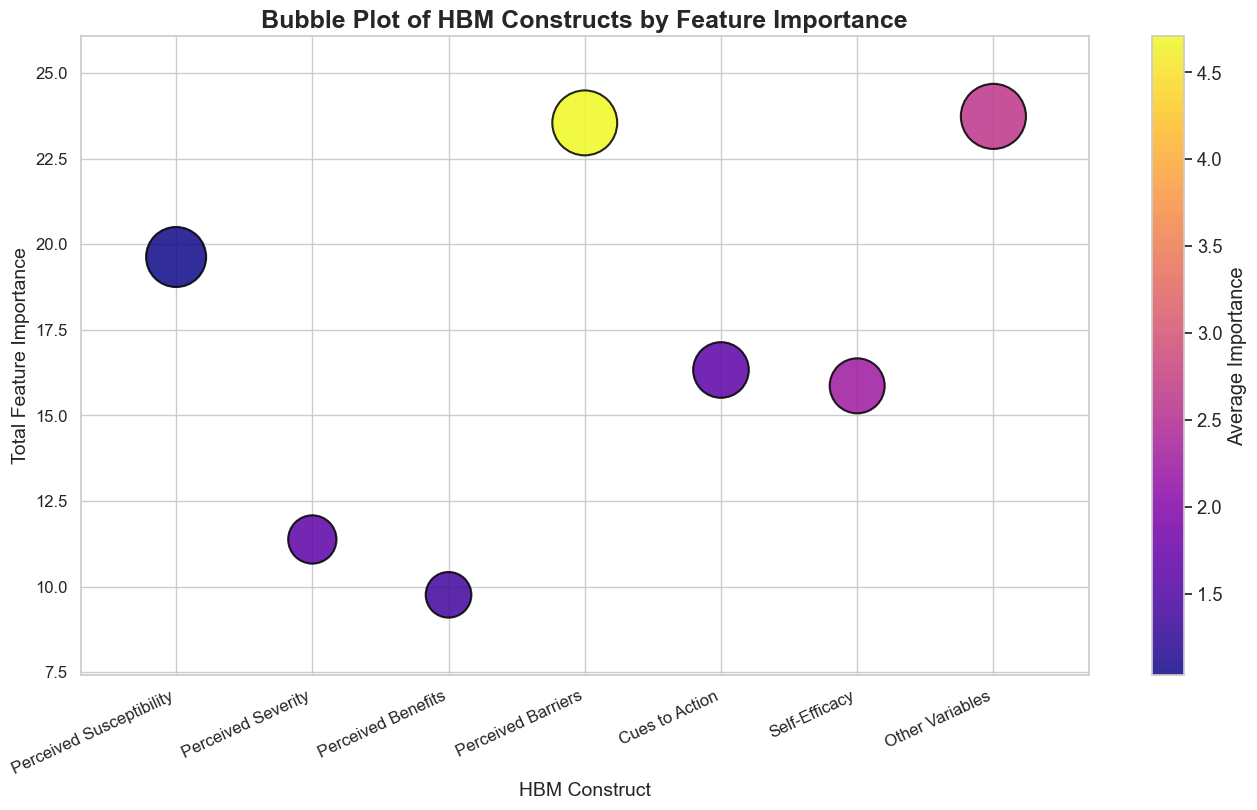

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the DataFrame that contains feature importances and their types
feature_importance_df = importance_df_cat

# Initialize a list to store aggregate importance for each HBM construct
construct_importance = []
for construct, features in hbm_features.items():
    # Filter features in the current construct that are present in the importance DataFrame
    matched = feature_importance_df[feature_importance_df['feature'].isin(features)]
    # Sum the importance values for the construct
    total_importance = matched['importance'].sum()
    # Count the number of features for the construct
    n_features = matched.shape[0]
    # Compute average importance per feature (if there are any features)
    avg_importance = matched['importance'].mean() if n_features > 0 else 0
    # Store the results in a dictionary appended to the list
    construct_importance.append({
        'construct': construct,
        'total_importance': total_importance,
        'avg_importance': avg_importance,
        'n_features': n_features
    })

# Convert the list of dictionaries to a DataFrame for plotting
bubble_df = pd.DataFrame(construct_importance)

# Set up the figure and seaborn style
plt.figure(figsize=(14, 9))
sns.set(style="whitegrid", font_scale=1.2)

# Calculate bubble sizes based on total importance (scaled for visibility)
bubble_sizes = bubble_df['total_importance'] * 80 + 300

# Use categorical positions for x-axis (improves control over margins)
x_pos = range(len(bubble_df))

# Create the scatter plot (bubble plot)
scatter = plt.scatter(
    x=x_pos,
    y=bubble_df['total_importance'],
    s=bubble_sizes,  # Bubble size
    c=bubble_df['avg_importance'],  # Bubble color
    cmap='plasma',
    alpha=0.85,
    edgecolors='black',
    linewidths=1.5
)

# Add colorbar for average importance
plt.colorbar(scatter, label='Average Importance')

# Set plot titles and axis labels
plt.title('Bubble Plot of HBM Constructs by Feature Importance', fontsize=18, weight='bold')
plt.xlabel('HBM Construct', fontsize=14)
plt.ylabel('Total Feature Importance', fontsize=14)

# Set x and y ticks (construct names, rotated for readability)
plt.xticks(x_pos, bubble_df['construct'], rotation=25, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add margin to x-axis so edge bubbles are not clipped
plt.xlim(-0.7, len(bubble_df)-0.3)

# Add margin to y-axis based on bubble size to avoid clipping
y_margin = max(bubble_sizes) ** 0.5 / 2 / 10  # approximate bubble radius for y margin
plt.ylim(bubble_df['total_importance'].min() - y_margin, bubble_df['total_importance'].max() + y_margin)

# Adjust subplot parameters for better layout
plt.tight_layout()
plt.subplots_adjust(left=0.07, right=0.97, bottom=0.2, top=0.91)  # extra bottom for rotated x labels

# Show the plot
plt.show()

In [29]:
#import ../data/processed/002-eda_final_for_report.pkl
with open('../data/processed/002-eda_final_for_report.pkl', 'rb') as f:
    df_for_report = pickle.load(f)

# Display the first few rows of the DataFrame to verify successful loading
df_for_report.head()  # Display the first few rows of the DataFrame to verify successful

df_for_report.columns # List all columns in the DataFrame

Index(['_STATE', 'DISPCODE', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'HLTHPLN1',
       'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3',
       'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2',
       'CHCKIDNY', 'DIABETE3', 'SEX', 'MARITAL', 'RENTHOM1', 'VETERAN3',
       'CHILDREN', 'WEIGHT2', 'HEIGHT3', 'QLACTLM2', 'USEEQUIP', 'SMOKE100',
       'USENOW3', 'EXERANY2', 'PNEUVAC3', 'HIVTST6', 'QSTVER', '_RFHLTH',
       '_HCVU651', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1', '_AGE65YR',
       '_AGE_G', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', '_SMOKER3',
       '_RFSMOK3', 'DRNKANY5', 'DROCDY3_', '_RFBING5', '_TOTINDA', '_RFSEAT3',
       'YEAR', 'MENTHLTH_TEMP_1', 'MENTHLTH_TEMP_2', 'PHYSHLTH_TEMP_1',
       'PHYSHLTH_TEMP_2'],
      dtype='object')

#### 5.2 Visualize the effect of HBM construct by AGE GROUP
CODE        AGE
***********************
1  =         Age 18 to 24

2  =         Age 25 to 34

3  =         Age 35 to 44

4  =         Age 45 to 54

5  =         Age 55 to 64

6  =         Age 65 or older


/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1660048883.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1660048883.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1660048883.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1660048883.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1660048883.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
 

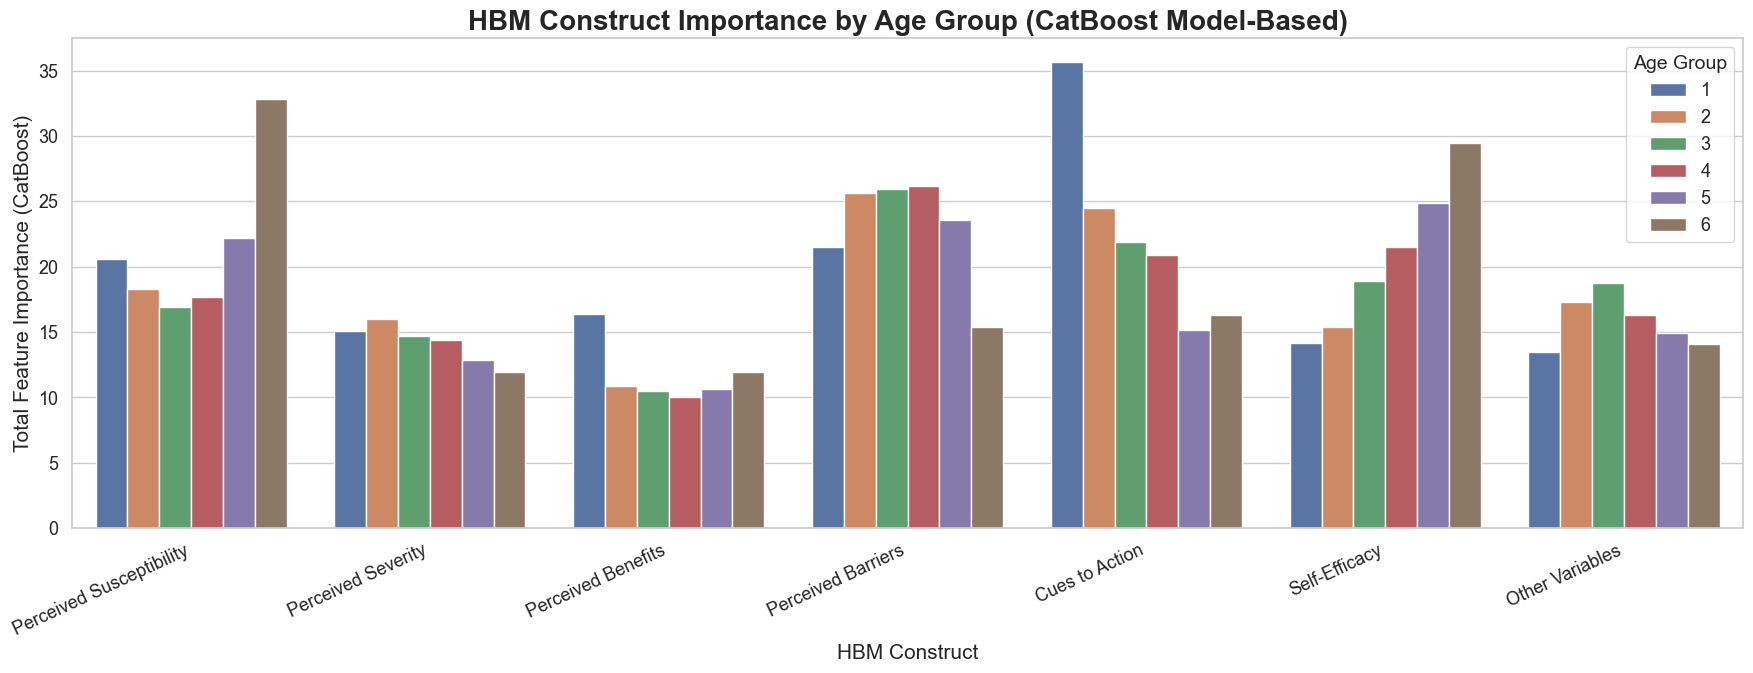

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from catboost import CatBoostClassifier  # or CatBoostRegressor as appropriate

# Prepare
age_codes = df_for_report['_AGE_G'].cat.categories if hasattr(df_for_report['_AGE_G'], 'cat') else df_for_report['_AGE_G'].unique()
palette = sns.color_palette("husl", len(age_codes))
bubble_age_list = []

# Features to use (excluding target and _AGE_G)
feature_cols = [col for col in df.columns if col not in ['_RFSMOK3', '_AGE_G']]  # replace 'target' as needed

# From feature_cols, keep only categorical (object or category dtype)
catboost_categorical_columns = [
    col for col in feature_cols 
    if df[col].dtype == "object" or df[col].dtype.name == "category"
]

for col in catboost_categorical_cols:
    df[col] = df[col].astype(str).fillna('7')

for idx, age_code in enumerate(age_codes):
    # Subset data for this age group
    df_age = df[df_for_report['_AGE_G'] == age_code]
    X = df_age[feature_cols]
    y = df_age['_RFSMOK3']  # replace 'target' with your actual target variable

    # Skip if too few samples to train
    if len(df_age) < 10 or y.nunique() < 2:
        continue

    # Train CatBoost model
    model = CatBoostClassifier(verbose=0, random_state=42,auto_class_weights='Balanced',
    cat_features=catboost_categorical_columns)
    model.fit(X, y)

    # Get importances, aligned with feature names
    importances = model.get_feature_importance()
    feature_importance_series = pd.Series(importances, index=feature_cols)

    # Aggregate by HBM constructs
    for construct, features in hbm_features.items():
        matched_features = [f for f in features if f in feature_importance_series.index]
        if not matched_features:
            continue
        imp_vals = feature_importance_series[matched_features]
        total_importance = imp_vals.sum()
        avg_importance = imp_vals.mean()
        n_features = len(matched_features)
        bubble_age_list.append({
            '_AGE_G': str(age_code),
            'construct': construct,
            'total_importance': total_importance,
            'avg_importance': avg_importance,
            'n_features': n_features,
            'color': palette[idx]
        })

bubble_age_df = pd.DataFrame(bubble_age_list)

# Plot: grouped barplot for easy comparison
plt.figure(figsize=(18, 7))
sns.set(style="whitegrid", font_scale=1.3)
ax = sns.barplot(
    data=bubble_age_df,
    x='construct',
    y='total_importance',
    hue='_AGE_G',
    ci=None
)
plt.title('HBM Construct Importance by Age Group (CatBoost Model-Based)', fontsize=20, weight='bold')
plt.xlabel('HBM Construct', fontsize=15)
plt.ylabel('Total Feature Importance (CatBoost)', fontsize=15)
plt.xticks(rotation=25, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.legend(title='Age Group', fontsize=13, title_fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
# Save the CatBoost model under the 'models' folder
model.save_model('../models/final_catboost_model_default.cbm')

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_values_sorted.values, y=shap_values_sorted.index, palette="viridis")


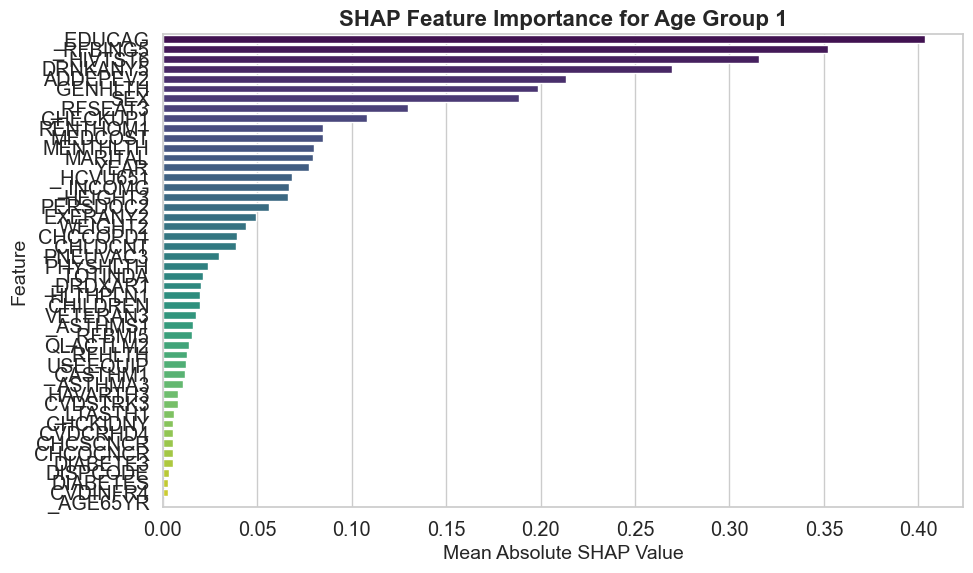

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_values_sorted.values, y=shap_values_sorted.index, palette="viridis")


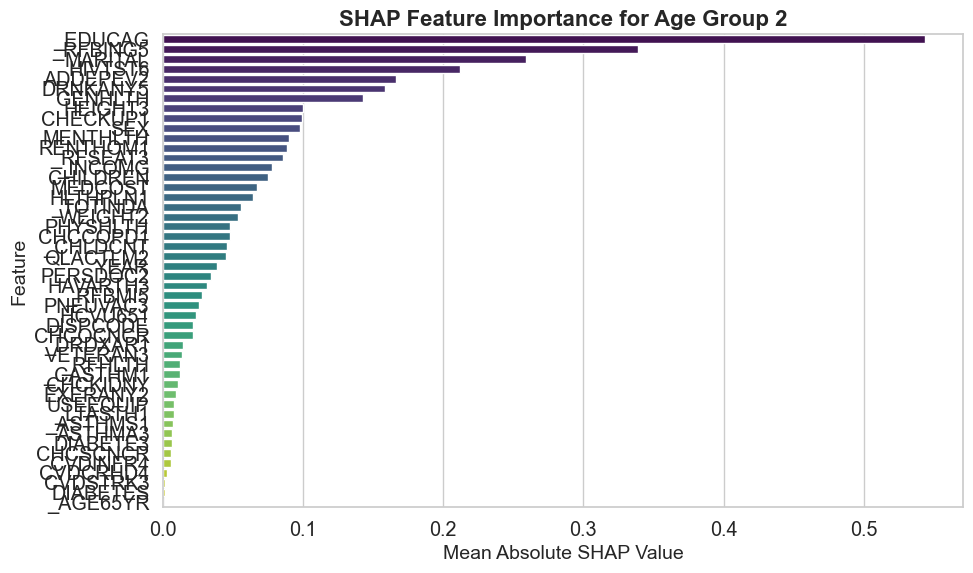

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_values_sorted.values, y=shap_values_sorted.index, palette="viridis")


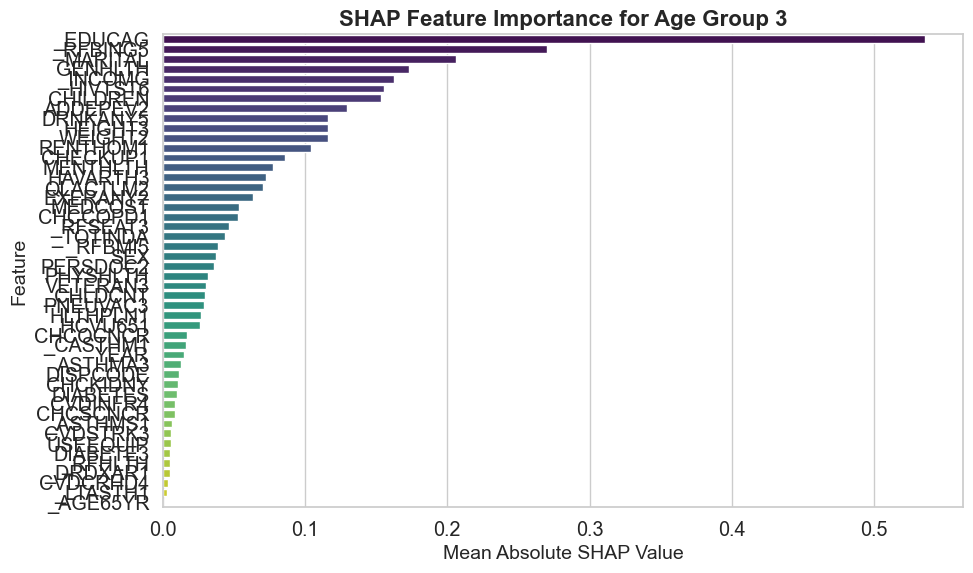

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_values_sorted.values, y=shap_values_sorted.index, palette="viridis")


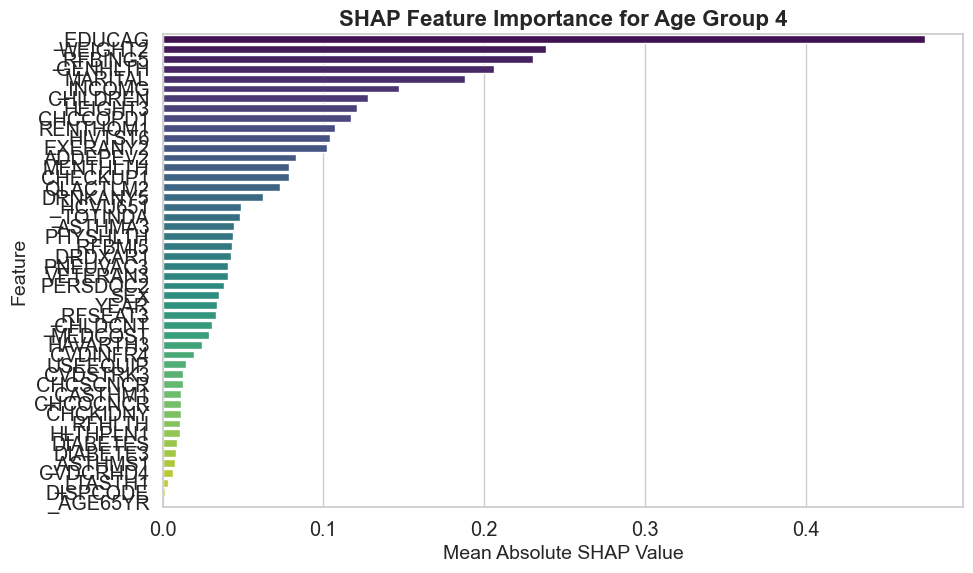

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_values_sorted.values, y=shap_values_sorted.index, palette="viridis")


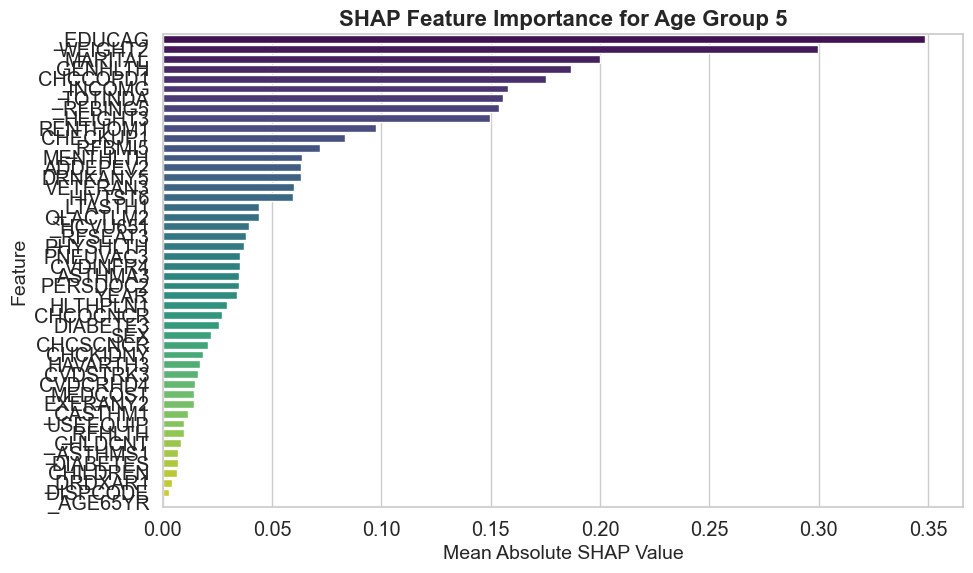

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]
/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_21288/1955215528.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shap_values_sorted.values, y=shap_values_sorted.index, palette="viridis")


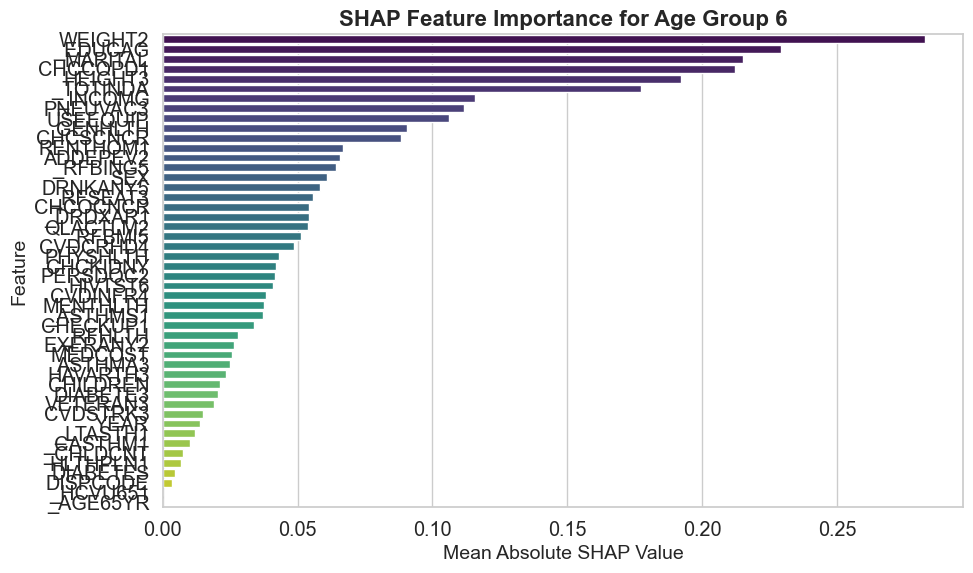

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from catboost import CatBoostClassifier  # or CatBoostRegressor as appropriate

from catboost import Pool

# Prepare
age_codes = df_for_report['_AGE_G'].cat.categories if hasattr(df_for_report['_AGE_G'], 'cat') else df_for_report['_AGE_G'].unique()
palette = sns.color_palette("husl", len(age_codes))
bubble_age_list = []

# Features to use (excluding target and _AGE_G)
feature_cols = [col for col in df.columns if col not in ['_RFSMOK3', '_AGE_G']]  # replace 'target' as needed

# From feature_cols, keep only categorical (object or category dtype)
catboost_categorical_columns = [
    col for col in feature_cols 
    if df[col].dtype == "object" or df[col].dtype.name == "category"
]

for col in catboost_categorical_cols:
    df[col] = df[col].astype(str).fillna('7')

for idx, age_code in enumerate(age_codes):
    # Subset data for this age group
    df_age = df[df_for_report['_AGE_G'] == age_code]
    X = df_age[feature_cols]
    y = df_age['_RFSMOK3']  # replace 'target' with your actual target variable

    # Skip if too few samples to train
    if len(df_age) < 10 or y.nunique() < 2:
        continue

    # Train CatBoost model
    model = CatBoostClassifier(verbose=0, random_state=42,auto_class_weights='Balanced',
    cat_features=catboost_categorical_columns)
    # Wrap your data in a Pool
    train_pool = Pool(data=X, label=y, cat_features=catboost_categorical_columns)
    # Training
    model.fit(train_pool)
    # Feature importance
    shap_values = model.get_feature_importance(train_pool,type='ShapValues')

    #agregate by HBM constructs by SHAP values
    # The first column is the expected value, so we take the mean absolute SHAP value
    shap_values_no_base = shap_values[:, :-1]
    shap_values_mean = np.abs(shap_values_no_base).mean(axis=0)
    # Create a Series for easier handling


    feature_importance_series = pd.Series(shap_values_mean, index=feature_cols)
    # feature_importance_series = pd.Series(importances, index=feature_cols)
    # feature_importance_series = pd.Series(importances, index=feature_cols)
    # feature_importance_series = pd.Series(importances, index=feature_cols)
    
    #plot the shap values for each age group
    plt.figure(figsize=(12, 6))  # wider figure helps spacing
    shap_values_sorted = feature_importance_series.sort_values(ascending=False)

    sns.barplot(
        x=shap_values_sorted.values, 
        y=shap_values_sorted.index, 
        palette="viridis"
    )

    plt.title(f'SHAP Feature Importance for Age Group {age_code}', fontsize=16, weight='bold')
    plt.xlabel('Mean Absolute SHAP Value', fontsize=14)
    plt.ylabel('Feature', fontsize=14)

    # Fix overlapping x-axis labels
    plt.xticks(rotation=45, ha='right')   # tilt labels
    plt.tick_params(axis='x', labelsize=12)  # bigger, readable ticks

    plt.tight_layout()
    plt.show()



    # # Aggregate by HBM constructs
    # for construct, features in hbm_features.items():
    #     matched_features = [f for f in features if f in feature_importance_series.index]
    #     if not matched_features:
    #         continue
    #     imp_vals = feature_importance_series[matched_features]
    #     total_importance = imp_vals.sum()
    #     avg_importance = imp_vals.mean()
    #     n_features = len(matched_features)
    #     bubble_age_list.append({
    #         '_AGE_G': str(age_code),
    #         'construct': construct,
    #         'total_importance': total_importance,
    #         'avg_importance': avg_importance,
    #         'n_features': n_features,
    #         'color': palette[idx]
    #     })

    #save the model for each age group
    model.save_model(f'../models/catboost_model_age_{age_code}.cbm')
        
# plot shap values for each age group

# bubble_age_df = pd.DataFrame(bubble_age_list)

# # Plot: grouped barplot for easy comparison
# plt.figure(figsize=(18, 7))
# sns.set(style="whitegrid", font_scale=1.3)
# ax = sns.barplot(
#     data=bubble_age_df,
#     x='construct',
#     y='total_importance',
#     hue='_AGE_G',
#     ci=None
# )
# plt.title('HBM Construct Importance by Age Group (CatBoost Model-Based)', fontsize=20, weight='bold')
# plt.xlabel('HBM Construct', fontsize=15)
# plt.ylabel('Total Feature Importance (CatBoost)', fontsize=15)
# plt.xticks(rotation=25, ha='right', fontsize=13)
# plt.yticks(fontsize=13)
# plt.legend(title='Age Group', fontsize=13, title_fontsize=14)
# plt.tight_layout()
# plt.show()

# 